[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/florvela/tinygpt/blob/main/01_pretraining/tinyGPT_pretraining.ipynb)

In [1]:
# Setup para Google Colab
import importlib.util
if importlib.util.find_spec('tinygpt') is None:
    base = 'https://raw.githubusercontent.com/florvela/tinygpt/main/01_pretraining'
    !wget -q $base/tinygpt.py
    !wget -q $base/trainer.py
    print('Descargados tinygpt.py y trainer.py')
else:
    print('tinygpt.py ya disponible (entorno local)')


tinygpt.py ya disponible (entorno local)


# TP-1 — TinyGPT: pretraining, decoding and Mixture of Experts

Author: Msc. Abraham R.

You will pretrain a very small GPT (a transformer decoder) at the character level on
Shakespeare, then work on it in two directions.

## TinyGPT Architectures

Tailored for the [NLP-II course](https://github.com/FIUBA-Posgrado-Inteligencia-Artificial/CEIA-LLMIAG) as we deal with architectures and theory, we will begin with a dense model, equivalent and based off GPT-2, finally we will end up in a model that consists of a **Mixture of Experts GPT**, equivalent to models like:
- DeepSeek-MoE/v2/v3/R1
- Qwen-MoE
- Mistral/Mixtral

**Part 1 — Inference.** The model gives you a probability distribution over the next
character. *Choosing* a character from it is a separate design decision, and it changes the
output far more than another epoch of training would.

**Part 2 — Architecture.** Replace the dense feed-forward block with a Mixture of Experts,
and measure what that buys and what it costs.

One model is trained once, at the top, and reused throughout.

## Tasks

**Part 1**
- Task I — implement `generateV2`: greedy, temperature, top-k and top-p.
- Task II — compare the decoding strategies and explain what each knob does.
- Task III — measure what the KV-cache actually buys you. Do not assume it wins.
- Task IV — read and explain the attention maps of your trained model.

**Part 2**
- Task V — implement top-k routing in `MoELayer.forward`.
- Task VI — train TinyGPT-MoE and compare it against the dense baseline.
- Task VII — measure expert utilization and diagnose routing collapse.
- Task VIII — implement [DeepSeekMoE](https://arxiv.org/pdf/2401.06066) and measure it.
- Task IX — your MoE is far slower per step than the dense model. Make it faster.

**Then**
- Task X — pretrain the *dense* model with a real subword GPT-2 tokenizer and compare properly. TP-2 and the
  TP-3 notebook depend on the checkpoint this produces.
- *Optional* — a load-balancing auxiliary loss.

## How to work on this

Every task a later cell depends on ships with a `check_*()` cell. Run it before moving on —
it costs seconds and catches the bugs that would otherwise show up as a flat loss curve half
an hour from now. All self-checks passing is the bar for submission.




In [2]:
import time
from typing import List, Optional

import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F
from torch import nn
from torch.optim import AdamW
from torch.optim.lr_scheduler import StepLR
from torch.utils.data import DataLoader

from tinygpt import (
    CharDataset,
    CharTokenizer,
    GPTConfig,
    MoEArgs,
    count_parameters,
    describe,
    free,
    load_checkpoint,
    get_device,
    load_tinyshakespeare,
    plot_losses,
    resume,
    run_training,
    trim_kv_cache,
    visualize_attention,
)
from trainer import Trainer

torch.manual_seed(1337)

## Resuming after a kernel restart

This notebook trains four models and keeps them in scope, so a restart loses all of them
and every cell below fails with `NameError`. The weights and loss curves are on disk, so
you do not have to retrain — run the cell below and skip forward to wherever you were.

Leave it alone on a fresh run: it only restores what is already finished.


In [3]:
def resume_all():
    """
    Rebuild whichever models already have a finished checkpoint.

    Run the cells above first -- definitions are instant, only training is not -- then call
    this. It restores each model and its loss curve, and skips anything whose class or
    config is not in scope yet.
    """
    import os

    g = globals()
    specs = [
        ("model",     "./checkpoints/tp1_dense",    "history",     ("config",)),
        ("moe_model", "./checkpoints/tp1_moe",      "history_moe", ("moe_config",)),
        ("ds_model",  "./checkpoints/tp1_deepseek", "history_ds",  ("ds_config",)),
        ("sub_model", "./checkpoints/tp1_subword",  "sub_history", ("sub_config",)),
    ]

    made, skipped = [], []
    for name, path, hist, needs in specs:
        if not os.path.exists(os.path.join(path, "checkpoint_final.pt")):
            continue
        if any(n not in g for n in needs):
            skipped.append(f"{name} (needs {', '.join(needs)})")
            continue
        # reuse the object if the config cell has already built an untrained one
        m = g.get(name) or g["TinyGPT"](g[needs[0]]).to(g["device"])
        g[name], g[hist] = m, g["resume"](m, path, map_location=g["device"])
        made.append(name)

    print("restored:", ", ".join(made) if made else "nothing")
    if skipped:
        print("not yet:", "; ".join(skipped))


# resume_all()   # uncomment after a kernel restart


## Downloading the dataset

In [4]:
# Lower this if training is slow on your machine.
N_CHARS = 100_000

text = load_tinyshakespeare(N_CHARS)
print(text[:400])
print(f"...\n\n{len(text):,} characters")

First Citizen:
Before we proceed any further, hear me speak.

All:
Speak, speak.

First Citizen:
You are all resolved rather to die than to famish?

All:
Resolved. resolved.

First Citizen:
First, you know Caius Marcius is chief enemy to the people.

All:
We know't, we know't.

First Citizen:
Let us kill him, and we'll have corn at our own price.
Is't a verdict?

All:
No more talking on't; let it 
...

100,000 characters


## Character-level encoding

`CharTokenizer` maps every distinct character to an integer id. One character == one token.

In [5]:
tokenizer = CharTokenizer(text)
print(f"vocab_size = {tokenizer.vocab_size}")
print(repr("".join(tokenizer.chars)))

data = torch.tensor(tokenizer.encode(text), dtype=torch.long)

# Train/validation split
split = int(0.9 * len(data))
train_data, val_data = data[:split], data[split:]
print(f"train {train_data.shape} | val {val_data.shape}")

vocab_size = 61
"\n !&',-.:;?ABCDEFGHIJKLMNOPQRSTUVWYabcdefghijklmnopqrstuvwxyz"
train torch.Size([90000]) | val torch.Size([10000])


## GPT configuration

`ff_class` lets Part 2 swap the feed-forward block for a MoE without touching the model code.

In [6]:
config = GPTConfig(vocab_size=tokenizer.vocab_size)
print(config)

GPTConfig(block_size=32, batch_size=64, n_embd=64, n_head=4, n_layer=2, dropout=0.1, vocab_size=61, bias=True, tie_weights=True, ff_class=None, moe_args=None)


## Dataloaders

In [7]:
# Use 0 on macOS/MPS; a few workers help on CUDA.
NUM_WORKERS = 0

train_dataset = CharDataset(train_data, config.block_size)
val_dataset = CharDataset(val_data, config.block_size)

train_loader = DataLoader(train_dataset, batch_size=config.batch_size, shuffle=True,
                          drop_last=True, pin_memory=True, num_workers=NUM_WORKERS)
val_loader = DataLoader(val_dataset, batch_size=config.batch_size, shuffle=False,
                        drop_last=True, pin_memory=True, num_workers=NUM_WORKERS)

print(f"{len(train_loader)} train batches | {len(val_loader)} val batches")

1405 train batches | 155 val batches


# The architecture

The next three cells are the whole model. *Read them before running them*. The rest of the
course builds on this code, and TP-2 imports it from `tinygpt.py` instead of redefining it.

Three details are worth your attention, because they are the ones that are easiest to get
silently wrong:

1. Every `forward` returns the same 3-tuple `(out, kv_cache, weights)`. Deciding the return
   shape from *whether a cache was passed in* is a classic bug: the very first decoding step
   has no cache to pass, so the cache never turns on and `use_cache=True` becomes a no-op
   you never notice.
2. The causal mask and the positional embeddings are both offset by the cache length. With
   a cache the model sees one new token, but that token is not at position 0.
3. All heads are projected and attended in one batched matmul, not in a Python loop over
   per-head modules. At this size wall-clock is dominated by kernel launches rather than
   arithmetic, so a loop over `n_head` modules costs several times the rest of the step —
   which is the same effect you will measure, and fix, in Task IX.


In [8]:
class MultiHeadAttention(nn.Module):
    """
    Causal multi-head self-attention, batched across heads.

    All heads are projected in one matmul and attended in one batched matmul, rather than
    looping over an `AttentionHead` module per head. The loop version is easier to read but
    launches `n_head` separate small kernels per layer, and at this model size wall-clock is
    dominated by kernel launches rather than arithmetic -- so the loop cost several times
    the whole rest of the step.

    The attention is still written out by hand (scores, causal mask, softmax) rather than
    calling F.scaled_dot_product_attention, because the mask is the thing being taught and
    SDPA cannot return attention weights for the visualisation task.

    Every forward returns the same 3-tuple `(out, kv_cache, weights)`; the trailing entries
    are `None` when not requested.
    """

    def __init__(self, args: GPTConfig):
        super().__init__()
        assert args.n_embd % args.n_head == 0, "n_embd must be divisible by n_head"
        self.n_head = args.n_head
        self.head_dim = args.n_embd // args.n_head

        # One projection for all heads: (B, T, C) -> (B, T, 3C), chunked K, Q, V.
        self.key_query_value = nn.Linear(args.n_embd, 3 * args.n_embd, bias=args.bias)
        self.proj = nn.Linear(args.n_embd, args.n_embd, bias=args.bias)

        self.attn_dropout = nn.Dropout(args.dropout)
        self.dropout = nn.Dropout(args.dropout)
        self.register_buffer(
            "tril", torch.tril(torch.ones(args.block_size, args.block_size))
        )

    def _split(self, t, B, T):
        """(B, T, C) -> (B, n_head, T, head_dim)"""
        return t.view(B, T, self.n_head, self.head_dim).transpose(1, 2)

    def forward(self, x, kv_cache=None, use_cache=False, return_weights=False):
        B, T, C = x.shape
        k, q, v = self.key_query_value(x).chunk(3, dim=-1)
        k, q, v = self._split(k, B, T), self._split(q, B, T), self._split(v, B, T)

        if kv_cache is not None:
            k_prev, v_prev = kv_cache.unbind(dim=0)      # (B, n_head, T_past, head_dim)
            k = torch.cat((k_prev, k), dim=2)
            v = torch.cat((v_prev, v), dim=2)

        new_cache = torch.stack((k, v)) if use_cache else None

        T_k = k.size(2)          # total keys attended to
        past = T_k - T           # how many of them came from the cache

        wei = q @ k.transpose(-2, -1) * (self.head_dim ** -0.5)   # (B, n_head, T, T_k)
        # Rows are offset by `past` so the mask stays correct with a KV-cache:
        # query at absolute position `past + t` may see keys 0..past + t.
        wei = wei.masked_fill(self.tril[past:T_k, :T_k] == 0, float("-inf"))
        wei = F.softmax(wei, dim=-1)
        wei = self.attn_dropout(wei)

        out = (wei @ v).transpose(1, 2).contiguous().view(B, T, C)
        out = self.dropout(self.proj(out))

        # (n_head, B, T, T_k) -- the layout visualize_attention expects
        weights = wei.transpose(0, 1) if return_weights else None
        return out, new_cache, weights

In [9]:
class FeedForward(nn.Module):
    """Dense MLP: the module Part 2 replaces with a MoE."""

    def __init__(self, config: GPTConfig):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(config.n_embd, 4 * config.n_embd),
            nn.ReLU(),
            nn.Linear(4 * config.n_embd, config.n_embd),
            nn.Dropout(config.dropout),
        )

    def forward(self, x):
        return self.net(x)


class Block(nn.Module):
    """Pre-norm transformer decoder block."""

    def __init__(self, config: GPTConfig):
        super().__init__()
        self.ln1 = nn.LayerNorm(config.n_embd)
        self.ln2 = nn.LayerNorm(config.n_embd)
        self.attn = MultiHeadAttention(config)

        ff_class = config.ff_class if config.ff_class is not None else FeedForward
        self.ff = ff_class(config)

    def forward(self, x, kv_cache=None, use_cache=False, return_weights=False):
        attn_out, new_cache, weights = self.attn(
            self.ln1(x), kv_cache=kv_cache, use_cache=use_cache, return_weights=return_weights
        )
        x = x + attn_out
        x = x + self.ff(self.ln2(x))
        return x, new_cache, weights

## TinyGPT

In [10]:
class TinyGPT(nn.Module):
    def __init__(self, config: GPTConfig):
        super().__init__()
        self.config = config
        self.token_emb = nn.Embedding(config.vocab_size, config.n_embd)
        self.pos_emb = nn.Embedding(config.block_size, config.n_embd)
        self.blocks = nn.ModuleList([Block(config) for _ in range(config.n_layer)])
        self.ln_f = nn.LayerNorm(config.n_embd)
        self.head = nn.Linear(config.n_embd, config.vocab_size, bias=False)

        if config.tie_weights:
            self.head.weight = self.token_emb.weight

    def forward(self, idx, kv_cache=None, use_cache=False, return_weights=False):
        """
        Args:
            idx:            (B, T) token ids.
            kv_cache:       list of per-layer caches from a previous call, or None.
            use_cache:      return an updated KV-cache alongside the logits.
            return_weights: return per-layer attention maps alongside the logits.

        Returns:
            `logits` when both flags are False (this is what `Trainer` expects),
            otherwise a tuple `(logits[, kv_cache][, attn_weights])`.

        Note the flags drive the return shape -- NOT whether `kv_cache` happens
        to be None. Deriving it from the input is how a cache silently never
        turns on: the very first decoding step has no cache to pass in.
        """
        B, T = idx.shape
        past_len = kv_cache[0].shape[-2] if kv_cache is not None else 0
        assert past_len + T <= self.config.block_size, (
            f"sequence of {past_len + T} exceeds block_size={self.config.block_size}"
        )

        tok_emb = self.token_emb(idx)
        # Positions must continue from where the cache left off, otherwise every
        # cached step re-uses position 0.
        pos = torch.arange(past_len, past_len + T, device=idx.device)
        x = tok_emb + self.pos_emb(pos)[None, :, :]

        new_kv_cache = [] if use_cache else None
        all_weights = [] if return_weights else None

        for i, block in enumerate(self.blocks):
            layer_cache = kv_cache[i] if kv_cache is not None else None
            x, updated_kv, weights = block(
                x, kv_cache=layer_cache, use_cache=use_cache, return_weights=return_weights
            )
            if use_cache:
                new_kv_cache.append(updated_kv)
            if return_weights:
                all_weights.append(weights)

        logits = self.head(self.ln_f(x))

        if not use_cache and not return_weights:
            return logits
        out = [logits]
        if use_cache:
            out.append(new_kv_cache)
        if return_weights:
            out.append(all_weights)
        return tuple(out)

    @torch.no_grad()
    def resize_token_embeddings(self, new_vocab_size: int) -> None:
        """
        Grows the input embedding and the output head to `new_vocab_size`,
        preserving every pretrained row.

        Needed when fine-tuning adds special tokens (chat/instruction markers)
        that the pretraining vocabulary did not contain.
        """
        old_vocab, n_embd = self.token_emb.weight.shape
        if new_vocab_size == old_vocab:
            return
        assert new_vocab_size > old_vocab, "shrinking the vocabulary is not supported"

        device = self.token_emb.weight.device
        dtype = self.token_emb.weight.dtype

        new_emb = nn.Embedding(new_vocab_size, n_embd, device=device, dtype=dtype)
        new_emb.weight.normal_(mean=0.0, std=0.02)
        new_emb.weight[:old_vocab] = self.token_emb.weight
        self.token_emb = new_emb

        new_head = nn.Linear(n_embd, new_vocab_size, bias=False, device=device, dtype=dtype)
        new_head.weight.normal_(mean=0.0, std=0.02)
        new_head.weight[:old_vocab] = self.head.weight
        self.head = new_head

        self.config.vocab_size = new_vocab_size

## Baseline generation (inference)

This is the function you upgrade in Task I. It samples from the *full* softmax at temperature 1.0 — no truncation, no temperature control.

In [11]:
@torch.no_grad()
def generate(
    model: nn.Module,
    tokenizer: CharTokenizer,
    prompt: str,
    max_new_tokens: int = 100,
    use_cache: bool = True,
    device: Optional[str] = None,
) -> str:
    """
    Baseline decoding: sample from the full softmax at temperature 1.0.

    This is the function TP-1 asks you to upgrade with greedy / temperature /
    top-k / top-p.
    """
    model.eval()
    device = device or next(model.parameters()).device
    block_size = model.config.block_size

    idx = torch.tensor(tokenizer.encode(prompt), dtype=torch.long, device=device)[None, :]
    kv_cache = None

    for _ in range(max_new_tokens):
        if kv_cache is None:
            idx_cond = idx[:, -block_size:]
        else:
            idx_cond = idx[:, -1:]

        out = model(idx_cond, kv_cache=kv_cache, use_cache=use_cache)
        if use_cache:
            logits, kv_cache = out
            # Never let the cache outgrow the context window.
            kv_cache = trim_kv_cache(kv_cache, block_size - 1)
        else:
            logits = out

        probs = F.softmax(logits[:, -1, :], dim=-1)
        next_token = torch.multinomial(probs, num_samples=1)
        idx = torch.cat((idx, next_token), dim=1)

    return tokenizer.decode(idx[0].tolist())

# Setup

In [12]:
device = get_device()
print(f"device: {device}")

model = TinyGPT(config).to(device)
describe(model, "TinyGPT (dense)")

# torch.compile traces the model and fuses kernels. It is a real speed-up on CUDA, it is
# unreliable on MPS (it crashes), and it buys little at this model size -- so it is enabled
# only where it helps.
#
# Note what it does to checkpoints: compiling wraps the module, so every state-dict key
# gains an "_orig_mod." prefix. That is why TP-2 and the serving notebook load weights
# through tinygpt.load_checkpoint, which strips it.
if device == "cuda":
    model = torch.compile(model)
    print("torch.compile enabled")


device: cuda
TinyGPT (dense): 106,048 parameters | 106,048 trainable (100.00%)
torch.compile enabled


In [13]:
EPOCHS = 2


def make_optimizer(params, lr: float = 1e-3):
    """
    8-bit Adam on CUDA, torch's AdamW everywhere else.

    bitsandbytes keeps optimizer state in 8 bits instead of 32, which roughly halves the
    memory Adam needs -- irrelevant at 800k parameters, and the reason you can fine-tune a
    7B model on one GPU.

    Every run in this notebook uses this, so the dense/MoE comparison never changes two
    things at once.
    """
    if device == "cuda":
        try:
            from bitsandbytes.optim import AdamW as bnbAdamW
            return bnbAdamW(params, lr=lr)
        except ImportError:
            print("bitsandbytes not installed (pip install bitsandbytes) -- using torch AdamW")
    return AdamW(params, lr=lr)


optimizer = make_optimizer(model.parameters())
scheduler = StepLR(optimizer, step_size=100, gamma=0.9)
loss_fn = torch.nn.CrossEntropyLoss()


bitsandbytes not installed (pip install bitsandbytes) -- using torch AdamW


# Training

Roughly a minute per epoch on a GPU, longer on CPU. Reduce `N_CHARS` above if you need it
faster.

## What runs differently on CUDA

Three optimisations are enabled automatically when a CUDA device is present and skipped
otherwise. None of them changes the maths — they change what the hardware does with it.

| | what it does | why it is CUDA-only |
|---|---|---|
| **8-bit Adam** (`make_optimizer`) | optimizer state in 8 bits instead of 32, roughly halving Adam's memory | `bitsandbytes` has no Apple Silicon build |
| **`torch.compile`** | traces the model and fuses kernels | unreliable on MPS; it crashes |
| **bfloat16 autocast** (`run_training`) | half the activation memory, faster matmuls on tensor cores | MPS autocast is incomplete and `GradScaler` does not support that backend |

At this model size none of them matters much. They matter enormously at the scale where
you would actually use them, which is why they are here rather than left out: 8-bit Adam is
the difference between fine-tuning a 7B model on one GPU and not.

`run_training(..., use_amp=True)` forces mixed precision on if you want to see what it does
on your hardware.

## A note on memory

This notebook trains four models in one kernel and keeps them alive, because later cells
compare them. Neither CUDA nor MPS returns freed blocks to the OS on its own, and the MoE's
variable-shaped gathers fragment the allocator badly — so without help the kernel grows
until the machine starts swapping.

`free()` drops the cache; `run_training` calls it after every run, and the cells below call
it again after releasing a trainer. If you run out of memory anyway, restart the kernel and
lower `N_CHARS`.


mixed precision: on (bfloat16)


  0%|          | 0/1405 [00:00<?, ?it/s]W0906 11:00:31.816000 23371 torch/_inductor/utils.py:1731] [0/0] Not enough SMs to use max_autotune_gemm mode
/usr/local/lib/python3.13/dist-packages/torch/_inductor/compile_fx.py:2941: UserWarning: Tesla T4 does not support bfloat16 compilation natively, skipping
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/torch/_inductor/compile_fx.py:2941: UserWarning: Tesla T4 does not support bfloat16 compilation natively, skipping
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/torch/_inductor/compile_fx.py:2941: UserWarning: Tesla T4 does not support bfloat16 compilation natively, skipping
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/torch/_inductor/compile_fx.py:2941: UserWarning: Tesla T4 does not support bfloat16 compilation natively, skipping
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/torch/_inductor/compile_fx.py:2941: UserWarning: Tesla T4 does not support bfloat16 compilation natively, skipping
  warni

epoch 1/2 | train 2.1591 | val 2.0328


val_loss 2.19305: 100%|██████████| 155/155 [00:00<00:00, 230.95it/s]


epoch 2/2 | train 2.0628 | val 1.9608


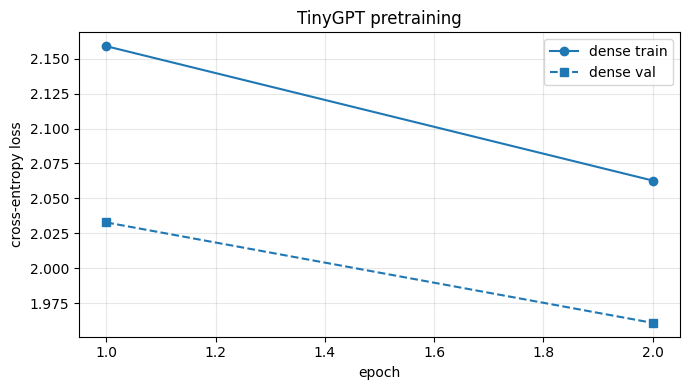

In [14]:
trainer = Trainer(
    model=model,
    train_data_loader=train_loader,
    test_data_loader=val_loader,
    loss_fn=loss_fn,
    gradient_accumulation_steps=1,
    optimizer=optimizer,
    scheduler=scheduler,
    device=device,
    save_dir="./checkpoints/tp1_dense",
    save_every_n=500,
)

history = run_training(trainer, epochs=EPOCHS)
plot_losses({"dense": history}, title="TinyGPT pretraining")

# The trainer pins the optimizer state; the model itself is still needed.
del trainer
free()

### Quick test

In [15]:
print(generate(model, tokenizer, "To be", max_new_tokens=300, use_cache=True))

To be heny my.

VOLUMNIA:
Ve, cousLALAA I wonomy, an sed He casrerate.
hyellloussercim yon s thowican! myosulourureans dsthufile mse ftleristyomadithedestigedatyimy wed;
Thelesvele ometouthr pederisooranes r
A luthe wheyedonRlluthinomeherded thisindr:
Onde mt s cinomyoustousteithe muty thinon ophesity he


# Task I — decoding strategies

The model gives you a probability distribution over the next character. *Choosing* a
character from that distribution is a separate design decision, and it changes the output
far more than another epoch of training would.

Implement `generateV2` below supporting:

- Greedy decoding (pick max probability token).
- Temperature sampling.
- top-k or top-p sampling.

Apply the temperature first, then top-k, then top-p, then renormalise and sample.
`top_k=None` and `top_p=None` mean no truncation, and `do_sample=False` ignores every
other knob.

### References
- [huggingface generate](https://huggingface.co/docs/transformers/main_classes/text_generation)
- [The Curious Case of Neural Text Degeneration (top-p)](https://arxiv.org/abs/1904.09751)


In [16]:
# TODO: implement greedy decoding, temperature, top-k and top-p.
@torch.no_grad()
def generateV2(
    model: nn.Module,
    tokenizer: CharTokenizer,
    prompt: str,
    max_new_tokens: int = 300,
    use_cache: bool = True,
    do_sample: bool = True,
    temperature: float = 1.0,
    top_k: Optional[int] = None,
    top_p: Optional[float] = None,
    device: Optional[str] = None,
) -> str:
    """
    Args:
        do_sample:   False -> greedy (arg-max); every other knob is ignored.
        temperature: >0. Lower is more deterministic, higher is more random.
        top_k:       keep the k most likely tokens, or None for no truncation.
        top_p:       keep the smallest set whose cumulative probability >= p,
                     or None for no truncation.

    Returns:
        The prompt plus `max_new_tokens` generated characters.
    """
    model.eval()
    device = device or next(model.parameters()).device
    block_size = model.config.block_size

    idx = torch.tensor(tokenizer.encode(prompt), dtype=torch.long, device=device)[None, :]
    kv_cache = None

    for _ in range(max_new_tokens):
        if kv_cache is None:
            idx_cond = idx[:, -block_size:]
        else:
            idx_cond = idx[:, -1:]

        out = model(idx_cond, kv_cache=kv_cache, use_cache=use_cache)
        if use_cache:
            logits, kv_cache = out
            # Never let the cache outgrow the context window.
            kv_cache = trim_kv_cache(kv_cache, block_size - 1)
        else:
            logits = out

        if not do_sample:
            probs = F.softmax(logits[:, -1, :], dim=-1)
            next_token = torch.argmax(probs, dim=-1, keepdim=True) # haciendolo greedy,
            idx = torch.cat((idx, next_token), dim=1)
            continue

        # me quedo solo con batch y vocab size
        logits = logits[:, -1, :]

        # temperatura
        if temperature > 0:
            logits /= temperature

        # en -inf los que no estan en el top K
        if top_k is not None:
            values, _ = torch.topk(logits, top_k)
            logits[logits < values[:, [-1]]] = -float('inf')

        if top_p is not None:
            sorted_logits, sorted_indices = torch.sort(logits, descending=True, dim=-1)
            cumulative_probs = torch.cumsum(F.softmax(sorted_logits, dim=-1), dim=-1)

            sorted_mask = cumulative_probs > top_p # candidatos a descartar
            # shift para conservar el token que cruza el umbral (y nunca borrar el #1)
            sorted_mask[..., 1:] = sorted_mask[..., :-1].clone()
            sorted_mask[..., 0] = False

            # traducir la mascara del orden ordenado al orden original del vocab
            mask = torch.zeros_like(logits, dtype=torch.bool)
            mask.scatter_(-1, sorted_indices, sorted_mask)

            logits = logits.masked_fill(mask, float('-inf'))

        probs = F.softmax(logits, dim=-1)
        next_token = torch.multinomial(probs, num_samples=1)
        idx = torch.cat((idx, next_token), dim=1)

    return tokenizer.decode(idx[0].tolist())
    # raise NotImplementedError("Task I")

## Self-check

Three properties that must hold if your implementation is right. Run this before
moving on — it catches most bugs.

In [17]:
def self_check():
    kw = dict(model=model, tokenizer=tokenizer, prompt="To be")

    # 1. greedy is deterministic
    a = generateV2(**kw, max_new_tokens=60, do_sample=False)
    b = generateV2(**kw, max_new_tokens=60, do_sample=False)
    assert a == b, "greedy decoding is not deterministic"

    # 2. top_k=1 collapses the distribution onto the arg-max, so it must equal greedy
    torch.manual_seed(0)
    c = generateV2(**kw, max_new_tokens=60, do_sample=True, top_k=1)
    assert c == a, "top_k=1 should reduce to greedy"

    # The next two look at a single step: over many steps a near-tie between the
    # top two logits will eventually break the exact match, which proves nothing.
    one = generateV2(**kw, max_new_tokens=1, do_sample=False)

    # 3. temperature -> 0 makes the softmax one-hot at the arg-max
    torch.manual_seed(0)
    assert generateV2(**kw, max_new_tokens=1, do_sample=True, temperature=1e-3) == one, \
        "temperature -> 0 should approach greedy"

    # 4. top_p -> 0 must keep exactly one token: the most likely one. This is the
    #    off-by-one from the hints -- a wrong comparison leaves an empty set here.
    torch.manual_seed(0)
    assert generateV2(**kw, max_new_tokens=1, do_sample=True, top_p=1e-9) == one, \
        "top_p -> 0 should keep the single most likely token"

    print("all checks passed")


self_check()

all checks passed


# Task II — compare the strategies

Run the grid below, read the samples, and answer the questions underneath.

In [18]:
PROMPT = "To be"

SETTINGS = [
    ("greedy",              dict(do_sample=False)),
    ("pure sampling (T=1)", dict(do_sample=True)),
    ("T=0.5",               dict(do_sample=True, temperature=0.5)),
    ("T=1.5",               dict(do_sample=True, temperature=1.5)),
    ("top_k=10",            dict(do_sample=True, top_k=10)),
    ("top_p=0.9",           dict(do_sample=True, top_p=0.9)),
    ("T=0.8 + top_p=0.9",   dict(do_sample=True, temperature=0.8, top_p=0.9)),
]

for name, kwargs in SETTINGS:
    torch.manual_seed(0)
    out = generateV2(model, tokenizer, PROMPT, max_new_tokens=200, **kwargs)
    print("=" * 70)
    print(f"### {name}")
    print(out)

### greedy
To be the the the the the the theano teano teano teano teno the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the t
### pure sampling (T=1)
To be he gain tied, to sa deffly angbl
W
Al.
Then? wirint t inacofrerendomumesthe, lobetiomasy chokce re ousala, matyoutedefyo'den ase ththin byma y ele misthedyin edoucest reerepe h tolimedofagerer?




W
### T=0.5
To be he the thim to them denot men ble meles mend wind t tendanofrethe gere thene lobetis sthenorece thedesatherouthedisthe ceatherun thende thet thele thousede weede testhenere the the medofoutre mutoren
### T=1.5
To beched tifruied, Eut muneffly-'t:
Fgem,lhiy; m? wir: r s:i, fo, he hyourm adeRa Mobehiomasyongrkce  pedamalm, mNhyoliedliy, adatuse r trce bymaindelepristimdyin edoRPeopereefne'th bokveldtayed
Ya?udoren
### top_k=10
To be he thim tied, to sa denat menge we
Ashind me wirint t inacofrerondonumestherelo whis styondicowe t was

## Questions

Answer in this cell.

1. Greedy decoding degenerates in a very specific way. Describe what happens and
   explain *why* the arg-max policy produces it.
2. `T=1.5` and `T=0.5` fail in opposite directions. Name both failure modes.
3. Top-k and top-p both truncate the distribution. Give a concrete situation where
   a fixed `k` is the wrong choice and top-p adapts better. (Think about how peaked
   the distribution is after `Th` versus after a space.)
4. Which setting would you ship, and why?

---

- es determinista. Me devuelve muchisimos "the"s porque seguramente la letra mas probable despues de un espacio es "t" y despues la "h", etc... entonces el mismo contexto siempre lleva a la misma salida y queda en un loop.

- ninguno de los dos tiene sentido, pero 1.5 parece ser mas gibberish, y el 0.5 tiene fragmentos que se repiten como "th" al comienzo de palabras y "the" al final o en el medio de estas.

- un k fijo usa siempre el mismo numero de candidatos (no importa si el modelo está seguro o indeciso) y top-p corta por prob acumulada... entonces se ajusta (pocos candidatos cuando el modelo esta seguro, muchos cuando está indeciso).

despues de "th" casi toda la probabilidad está en la letra "e", lo correcto seria tomar en cuenta 1 o 2 caracteres, pero con un k fijo alto tendriamos muchos candidatos que no nos sirven. top p se adapta mejor porque la probabilidad está concentrada en la letra que el modelo esta muy seguro que va.

despues de un espacio tenemos mas opciones porque empieza una nueva palabra.. si un k fijo es muy chico, me saca las probabilidades de posibles palabras. cada letra aporta poca probabilidade, entonces con top p conservamos bastantes.

- T=0.8 y P=0.9
porque sabemos que un top p se adapta bien y recorta opciones cuando el modelo está seguro. le sumamos temperatura para que haya algo de randomness pero sin que sea gibberish, nos sirve para salir de loops

# Task III — what does the KV-cache actually buy you?

### Theory
Without a cache, generating token *n* re-runs attention over all *n* previous
tokens. With a cache, the keys and values of those tokens are reused and only the
new token is projected. Asymptotically that turns O(N²) generation into O(N).

### Task
**Measure whether the theory actually holds here, and do not assume the
cache wins** — report the number you get, whatever it is, and then explain it.

n=  50 | cache=0.092s | no-cache=0.088s | speed-up x0.95
n= 100 | cache=0.261s | no-cache=0.221s | speed-up x0.85
n= 200 | cache=0.356s | no-cache=0.343s | speed-up x0.97
n= 400 | cache=0.725s | no-cache=0.694s | speed-up x0.96


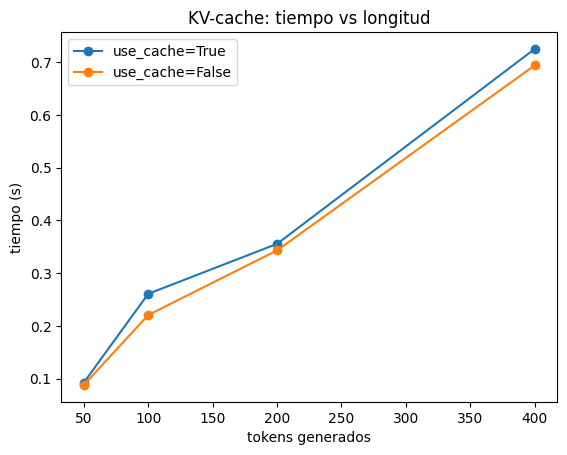

In [19]:
# TODO: time generateV2 with and without the KV-cache, for several lengths.
def benchmark_cache(lengths=(50, 100, 200, 400), repeats: int = 3):
    """
    For each length, time generation with use_cache=True and use_cache=False and
    print the speed-up. Plot tokens vs. wall-clock time for both.
    """
    device = next(model.parameters()).device

    def time_one(n, use_cache):
        # warm-up (NO se mide)
        generateV2(model, tokenizer, "To be", max_new_tokens=n, use_cache=use_cache)
        best = float("inf")
        for _ in range(repeats):
            if device.type == "cuda":
                torch.cuda.synchronize()
            t0 = time.perf_counter()
            generateV2(model, tokenizer, "To be", max_new_tokens=n, use_cache=use_cache)
            if device.type == "cuda":
                torch.cuda.synchronize()
            best = min(best, time.perf_counter() - t0)
        return best

    times_cached, times_uncached = [], []
    for n in lengths:
        tc = time_one(n, True)
        tu = time_one(n, False)
        times_cached.append(tc)
        times_uncached.append(tu)
        print(f"n={n:4d} | cache={tc:.3f}s | no-cache={tu:.3f}s | speed-up x{tu/tc:.2f}")

    plt.plot(lengths, times_cached,   marker="o", label="use_cache=True")
    plt.plot(lengths, times_uncached, marker="o", label="use_cache=False")
    plt.xlabel("tokens generados")
    plt.ylabel("tiempo (s)")
    plt.legend()
    plt.title("KV-cache: tiempo vs longitud")
    plt.show()
    # raise NotImplementedError("Task III")


benchmark_cache()

## Questions

1. Did the cache make generation faster? Report your numbers. If it did not,
   explain where the time actually goes: count the kernel launches and the tensor
   allocations this implementation performs per decoding step, and weigh them against the
   arithmetic the cache saves.
2. Asymptotically the cache is a clear win. Name the specific properties of *this*
   implementation and *this* model size that hide that win, and describe a setting
   (model size, sequence length, attention implementation) where it would clearly show up.
3. What does the cache cost you in memory? Give the formula in terms of `n_layer`,
   `n_head`, `head_dim`, batch size and sequence length, and evaluate it for this model.
4. Cached and uncached decoding produce identical text while the sequence fits in
   the context window, and diverge after that. Why?

---

- no. de hecho mas lento... 0.85 veces la velocidad hasta 0.97 veces. porque el ahorro de la cache es para los K y V de los tokens pasados, pero tenemos un block size de 32 que hace de tope y el modelo es muy chiquito. ademas hacemos mas operaciones:

  * torch.cat para pegar las K y V nuevas a las viejas
  * torch.stach para armar el cache nuevo
  * trim_kv_cache para recortarlo


- No gana por tres razones propias de este caso:
  
  * block_size = 32: el contexto es minusculo, asi que el termino O(N^2) que
    el cache ataca nunca crece
  * Modelo diminuto (n_embd=64, 2 capas): la aritmetica por paso es
    despreciable, y lo que domina es el costo fijo por paso (kernel launches y
    alocaciones). El cache encima agrega operaciones (cat, stack, trim)
  * Atencion escrita a mano y corriendo en CPU: ese costo fijo por paso pesa
    todavia mas.

  Se veria la ventaja con:
  * modelo grande (miles de millones de params),
  * secuencias largas (miles de tokens, block_size grande) y
  * GPU con atencion optimizada.

- midiendo el costo de cache:

guarda K y V, para cada capa, cada cabeza, cada posición pasada:

si se que la cantidad de elementos de K = n_layer * n_head * head_dim * batch * seq_len

y la cant de elementos de V es lo mismo

cant de elementos totales = elems de K + elems de V

elems = 2 * (n_layer * n_head * head_dim * batch * seq_len)

elems =  2 * 2 * 4 * 16 * 1 * 32 = 8192

si hablamos de memoria y queremos medir en bytes = elems * bytes por elemento

entonces 8192 * 4 = 32768  ===> 32 KB

- cuando la secuencia entra el context window se produce la misma secuencia porque el cache guarda las mismas K/V que recalculariamos, entonces tenemos las mismas posiciones, mismos logits y con misma seed tenemos mismo texto.

cuando no entra, diverge porque sin cache toma los ultimos 32 tokens y los recodifica desde la posicion 0 en cada paso. con cache se recorta el cache que fue construido con las posiciones absolutas de cuando cada token entró. entonces el conjunto de posiciones y las K/V no coinciden, hay logits diferentes.

# Task IV — visualizing attention

A GPT completes text. Let us look at what the heads of your trained model
actually attend to.

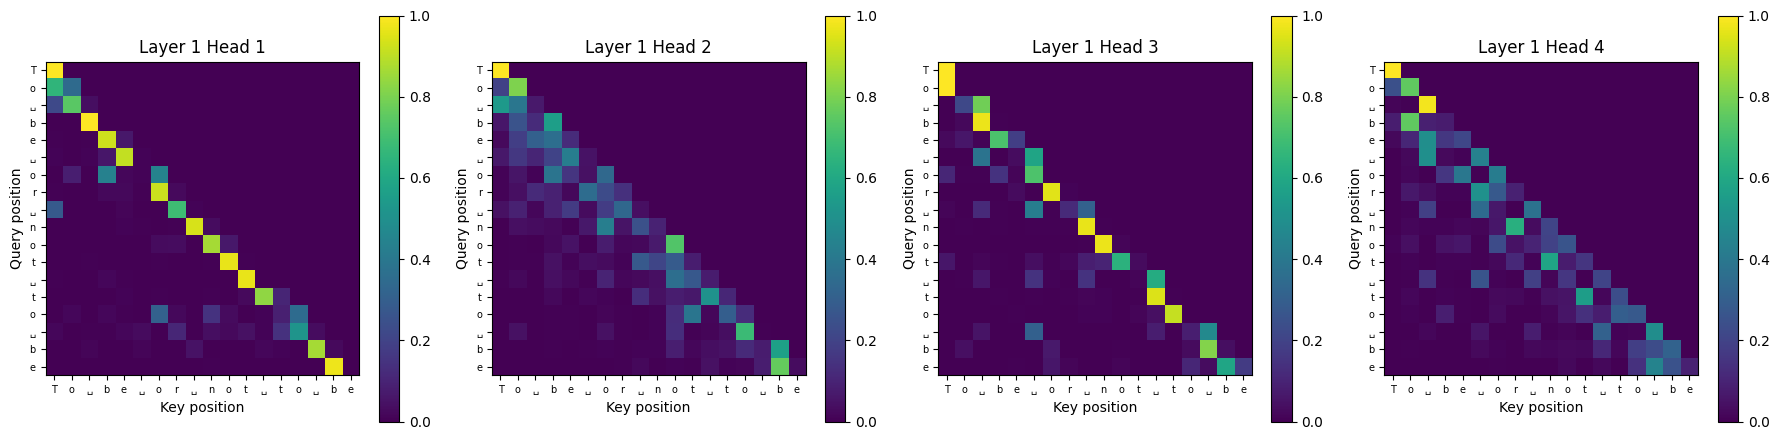

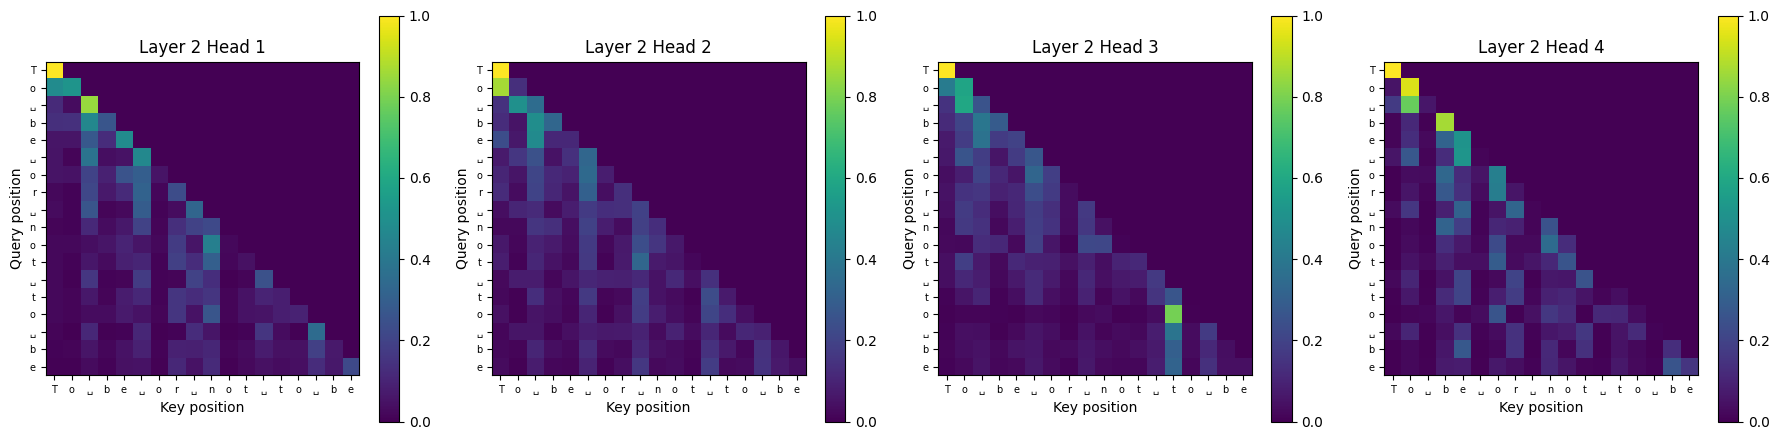

In [20]:
visualize_attention(model, tokenizer, "To be or not to be")

## Questions

1. Every map is lower-triangular. Which line of `AttentionHead.forward` causes that,
   and what would break if you removed it?
2. Find one head that attends mostly to the immediately previous character and one
   that spreads its mass more widely. What is each one plausibly doing?

---

- la linea es:

` wei = wei.masked_fill(self.tril[past:T_k, :T_k] == 0, float("-inf"))`

si la borramos,  cada token podria mirar a tokens futuros, pero estamos entrenando para predecir el proximo token... si la eliminamos podria ver el "futuro" entonces el error de entrenamiento seria casi 0 pero el modelo no aprenderia nada util y para generar texto no funcionaria porque los tokens futuros todavia no existen. esta linea nos impide que el modelo haga trampa.

- una head que mostly to the immediate prev character seria Layer 1 Head 3. usa el token anterior como pista para el siguiente token.

una que spreads more widely quizas layer 2 head 1 o layer 2 head 2, porque hay mas atencion desparramada en muchas casillas. tiene contexto mas amplio y se fija en toda la secuencia hasta ahi en vez de fijarse solo en el vecino, integra informacion de toda la secuencia hasta ahi.

---

# Part 2 — Architecture

Part 1 changed how you *sample* from a trained model. Part 2 changes the model itself.

You will replace the dense feed-forward block with a Mixture of Experts — the idea
behind Mixtral, DeepSeek and Qwen-MoE — and compare it against the model you just trained.
No retraining of the baseline: the `model` and `history` from Part 1 are the comparison.

In a dense transformer every token goes through the *same* feed-forward network. A MoE
replaces that single FFN with `E` experts and a small gate that picks `k` of them
per token. Total parameters grow with `E`; the parameters *used* for any given token grow
only with `k`. You buy capacity without paying the matching compute.

The costs are real too, and you will measure them: the gate can collapse onto a few experts
and starve the rest, routing is discrete so gradients only reach the experts that were
selected, and a naive implementation is *slower* than the dense one at this scale.

### References
- [Mixtral of Experts](https://arxiv.org/abs/2401.04088)
- [Outrageously Large Neural Networks (sparsely-gated MoE)](https://arxiv.org/abs/1701.06538)
- [Switch Transformers](https://arxiv.org/abs/2101.03961)
- `Clase_IV_MoEs.pdf`


In [ ]:
def build_trainer(model, save_dir, lr=1e-3):
    """Same optimizer, scheduler and loss for every run, so only the architecture changes."""
    optimizer = make_optimizer(model.parameters(), lr=lr)
    scheduler = StepLR(optimizer, step_size=100, gamma=0.9)
    return Trainer(
        model=model,
        train_data_loader=train_loader,
        test_data_loader=val_loader,
        loss_fn=torch.nn.CrossEntropyLoss(),
        gradient_accumulation_steps=1,
        optimizer=optimizer,
        scheduler=scheduler,
        device=device,
        save_dir=save_dir,
        save_every_n=500,
    )

## The building blocks

Two pieces, both given.

An expert is an FFN: the same `Linear -> ReLU -> Linear -> Dropout` stack the dense model
uses. Nothing exotic — the interesting part is who gets routed to it.

The gate scores every expert for every token, mapping `(B, T, n_embd)` to
`(B, T, num_experts)`. A single `nn.Linear`, no bias, no activation; the softmax happens
later, over the top-k scores only.

`Expert` takes its hidden width from `config.moe_args.expert_hidden_mult` rather than
hard-coding 4x. You will need that in Task VIII.


In [ ]:
class Expert(nn.Module):
    """
    A single expert MLP inside a MoE layer.

    The hidden width comes from moe_args.expert_hidden_mult (4.0 is standard), so that
    fine-grained segmentation can shrink each expert without touching this class.
    """

    def __init__(self, config: GPTConfig) -> None:
        super().__init__()
        hidden = int(config.moe_args.expert_hidden_mult * config.n_embd)
        self.net = nn.Sequential(
            nn.Linear(config.n_embd, hidden),
            nn.ReLU(),
            nn.Linear(hidden, config.n_embd),
            nn.Dropout(config.dropout),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.net(x)


class Gate(nn.Module):
    """
    Router: scores each expert for each token. Returns raw logits, not probabilities.
    """

    def __init__(self, config: GPTConfig) -> None:
        super().__init__()
        self.proj = nn.Linear(config.n_embd, config.moe_args.num_experts, bias=False)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.proj(x)


# Task V — top-k routing

This is the core of the assignment. `MoELayer.forward` takes `x` of shape
`(B, T, n_embd)` and returns the same shape.

The gate scores every expert for every token; you keep the top `k`, softmax over just
those, run each selected expert, and combine its output weighted by the gate. Routing is
per token, not per sequence — so flatten `(B, T, C)` to `(N, C)` before you route.

Two things to get right, because both fail quietly:

- The softmax goes *after* the top-k, over the selected experts only. Normalising before
  truncating leaves per-token weights that no longer sum to 1.
- Everything must stay differentiable, or the gate never learns.

Before returning, store the routing decision on the module —
`self.last_indices = indices.detach()` and
`self.last_gate_probs = F.softmax(logits, dim=-1).detach()` — Task VII reads these.


In [ ]:
class MoELayer(nn.Module):
    """
    Sparsely-gated Mixture of Experts feed-forward layer.
    """

    def __init__(self, experts: List[nn.Module], gate: nn.Module, moe_args: MoEArgs):
        super().__init__()
        self.experts = nn.ModuleList(experts)
        self.gate = gate
        self.args = moe_args
        self.last_indices = None
        self.last_gate_probs = None

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # TODO: Task V
        raise NotImplementedError


class MoEFFN(nn.Module):
    """
    Drop-in replacement for FeedForward. Assigned to config.ff_class so that
    Block picks it up without any change to the model code.
    """

    def __init__(self, config: GPTConfig):
        super().__init__()
        assert config.moe_args is not None, "config.moe_args must be set to use MoEFFN"
        self.moe = MoELayer(
            experts=[Expert(config) for _ in range(config.moe_args.num_experts)],
            gate=Gate(config),
            moe_args=config.moe_args,
        )

    def forward(self, x):
        return self.moe(x)

## Self-check

Run this before training. It costs seconds and catches the routing bugs that would otherwise show up as a flat loss curve half an hour from now.

In [ ]:
def check_moe():
    cfg = GPTConfig(vocab_size=tokenizer.vocab_size, n_embd=32, dropout=0.0,
                    moe_args=MoEArgs(num_experts=4, num_experts_per_token=2))
    layer = MoELayer([Expert(cfg) for _ in range(4)], Gate(cfg), cfg.moe_args)
    layer.eval()
    x = torch.randn(2, 5, 32)

    # 1. shape is preserved
    out = layer(x)
    assert out.shape == x.shape, f"{out.shape} != {x.shape}"

    # 2. gradients reach both the experts and the gate
    out.sum().backward()
    assert layer.gate.proj.weight.grad is not None, "the gate receives no gradient"
    assert any(p.grad is not None and p.grad.abs().sum() > 0
               for p in layer.experts.parameters()), "no expert receives gradient"

    # 3. with k=1 the output must equal the selected expert, untouched
    cfg1 = GPTConfig(vocab_size=tokenizer.vocab_size, n_embd=32, dropout=0.0,
                     moe_args=MoEArgs(num_experts=4, num_experts_per_token=1))
    top1 = MoELayer([Expert(cfg1) for _ in range(4)], Gate(cfg1), cfg1.moe_args)
    top1.eval()
    with torch.no_grad():
        y = top1(x)
        choice = top1.gate(x).argmax(dim=-1)          # (B, T)
        expected = torch.stack([
            torch.stack([top1.experts[int(choice[b, t])](x[b, t]) for t in range(x.shape[1])])
            for b in range(x.shape[0])
        ])
    err = (y - expected).abs().max().item()
    assert err < 1e-5, f"top-1 routing mismatch: {err}"

    # 4. routing must be per token, not per sequence
    assert top1.last_indices is not None, "store last_indices (see Task V)"
    assert top1.last_indices.shape[0] == x.shape[0] * x.shape[1]

    print("all checks passed")


check_moe()

# Task VI — train TinyGPT-MoE

`Block` reads `config.ff_class`, so turning TinyGPT into a MoE is a configuration
change, not a code change.

In [ ]:
moe_config = GPTConfig(
    vocab_size=tokenizer.vocab_size,
    ff_class=MoEFFN,
    moe_args=MoEArgs(num_experts=4, num_experts_per_token=2),
)

moe_model = TinyGPT(moe_config).to(device)
if device == "cuda":
    moe_model = torch.compile(moe_model)

describe(model, "TinyGPT (dense)")
describe(moe_model, f"TinyGPT-MoE (E={moe_config.moe_args.num_experts}, k={moe_config.moe_args.num_experts_per_token})")

dense_total, _ = count_parameters(model)
moe_total, _ = count_parameters(moe_model)
print(f"\nparameter growth: {moe_total / dense_total:.2f}x")

In [ ]:
history_moe = run_training(build_trainer(moe_model, "./checkpoints/tp1_moe"), epochs=EPOCHS)
plot_losses({"dense": history, "moe": history_moe}, title="dense vs MoE")
free()

# Task VII — expert utilization

A MoE that routes 90% of its tokens to one expert is a dense model that wastes
memory. Measure whether yours actually spreads the load.

Using `last_indices` (stored by your `MoELayer.forward`), run a few validation
batches and, per layer, count how many tokens went to each expert. Plot it as a
bar chart, one group per layer, and print the fraction of tokens each expert saw.

A perfectly balanced layer sends `k / E` of the tokens to each expert.

In [ ]:
# TODO: Task VII
@torch.no_grad()
def expert_utilization(model, loader, n_batches: int = 20):
    """
    Returns a tensor of shape (n_layer, num_experts) with the fraction of tokens
    routed to each expert, and plots it.

    Hint: for each block, model.blocks[i].ff.moe.last_indices holds the (N, k)
    selection from the most recent forward pass. Use torch.bincount.
    """
    raise NotImplementedError


utilization = expert_utilization(moe_model, val_loader)

## Questions

1. If one expert is starved, explain the feedback loop that got you there. Why is it
   self-reinforcing?
2. Routing is a `topk`, which has no useful gradient. So how does the gate learn
   anything at all? Trace the path from the loss back to `gate.proj.weight`.

---

-
-
-

# Task VIII — DeepSeekMoE

Your current MoE is a legacy design: `E` equal experts, pick the top `k`. Read
[DeepSeekMoE (Dai et al., 2024)](https://arxiv.org/abs/2401.06066) and implement its two
changes. They are what makes DeepSeek-V2 and V3 and modern verisons use, and both are small deltas on the
layer you already wrote.

**Fine-grained expert segmentation.** Split each expert into `m` smaller ones: multiply
`num_experts` and `num_experts_per_token` by `m`, and divide each expert's hidden width by
`m`. Total parameters and per-token compute are unchanged. What grows is the number of
routing *combinations* — from "choose 2 of 4" to "choose 4 of 8" — so a token can express
a more specific mixture.

**Shared expert isolation.** Reserve `num_shared_experts` experts that every token passes
through, always, outside the top-k. The argument: knowledge common to all tokens
(punctuation, spacing, basic English) otherwise has to be duplicated inside every routed
expert. Hand it to a shared expert and the routed ones are free to specialise.

Implement `DeepSeekMoELayer`. Both settings live in `MoEArgs` already
(`num_shared_experts`, `expert_hidden_mult`); `Expert` reads the width from config, so you
should not need to touch it.

Then train it against your Task VI MoE at **matched active parameters** and report loss,
expert utilization, and per-step time.

### Set your expectations first

Write down what you predict, then measure. This model is 2 layers at `n_embd=64` trained
on 100k characters. Segmenting 4 experts into 8 leaves each with a hidden width of 128.
The paper's results are at 2B–145B parameters on hundreds of billions of tokens.

**A null result here is the correct result, and explaining it is the task.** Reproducing a
2024 architecture and then honestly reporting that its benefit does not appear at your
scale is worth more than a number that went the right way by luck.


In [ ]:
class DeepSeekMoELayer(nn.Module):
    """
    MoE with fine-grained expert segmentation and shared experts (arXiv:2401.06066).

    Shared experts run for every token, outside the top-k. Routed experts are selected as
    before. Store last_indices / last_gate_probs for the routed experts only, so Task VII's
    utilization plot still works.
    """

    def __init__(self, config: GPTConfig):
        super().__init__()
        # TODO: Task VIII
        raise NotImplementedError

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # TODO: Task VIII
        raise NotImplementedError


class DeepSeekMoEFFN(nn.Module):
    """Drop-in for config.ff_class, like MoEFFN."""

    def __init__(self, config: GPTConfig):
        super().__init__()
        self.moe = DeepSeekMoELayer(config)

    def forward(self, x):
        return self.moe(x)


In [ ]:
# Fine-grained segmentation is compute-neutral: 4 experts x top-2 at 4.0x hidden becomes
# 8 x top-4 at 2.0x, and the active FFN parameters per token are identical either way.
# What changes is the number of routing combinations, from C(4,2)=6 to C(8,4)=70.
#
# The shared expert is NOT free -- it runs for every token, adding one expert's worth on
# top. Question 1 asks you to work out exactly how much, and whether that undermines the
# comparison.
#
# SEGMENTS=2 keeps this affordable: 8 routed experts + 1 shared is 9 sequential expert
# calls per layer, against 17 at SEGMENTS=4. The paper segments far more aggressively --
# set this to 4 if you have the compute and want to see whether it changes anything.
SEGMENTS = 2

ds_config = GPTConfig(
    vocab_size=tokenizer.vocab_size,
    ff_class=DeepSeekMoEFFN,
    moe_args=MoEArgs(
        num_experts=4 * SEGMENTS,
        num_experts_per_token=2 * SEGMENTS,
        num_shared_experts=1,
        expert_hidden_mult=4.0 / SEGMENTS,
    ),
)

ds_model = TinyGPT(ds_config).to(device)
if device == "cuda":
    ds_model = torch.compile(ds_model)

describe(moe_model, "MoE (Task VI)")
describe(ds_model, "DeepSeekMoE")


In [ ]:
history_ds = run_training(build_trainer(ds_model, "./checkpoints/tp1_deepseek"), epochs=EPOCHS)
plot_losses({"dense": history, "moe": history_moe, "deepseek": history_ds},
            title="dense vs MoE vs DeepSeekMoE")
free()


## Questions

1. Re-run the Task VII utilization plot on the DeepSeekMoE model. With 8 routed experts
   instead of 4, is the load more or less balanced, and why would you expect that
   *before* looking?
2. The shared expert receives every token. Inspect its output magnitude against a routed
   expert's. Is it doing what the paper claims — absorbing common structure — or has it
   just become a second dense FFN?
3. The paper reports clear gains; you probably did not reproduce them. Give the most
   likely reason, and describe the smallest experiment that would test whether scale is
   the explanation.

---

-
-
-
-
-


# Task IX — make it fast

Open-ended. There is no reference solution and no checker.

You measured it in Task VI: the MoE trains at roughly **30x the per-step cost** of the
dense model, for *less* arithmetic. Task VIII made it worse — 16 experts instead of 4 means
16 sequential expert calls per layer.

**Make it faster. Report what you tried, what worked, what did not, and why.**

Rules: the output must stay numerically equivalent to your Task V implementation (write a
test that proves it), and the model must still train. Beyond that, anything goes.

Some directions, not a checklist — you are not required to use any of them:

- Time the *second* epoch, never the first: lazy kernel compilation makes epoch 1 about
  2.4x slower and will flatter or ruin any change you make.
- Where does the time actually go? Profile before optimising. `torch.profiler`, or time the
  pieces by hand. The answer is not where most people guess.
- `torch.where` returns a variable-length tensor, so it forces a GPU→CPU synchronisation.
  You call it once per expert per layer.
- Sorting tokens by expert once turns a scatter into contiguous slices.
- Padding each expert to a fixed capacity makes the shapes static, which is what lets you
  batch experts into one `torch.bmm`. What does capacity padding cost you in correctness?
- Small matmuls leave the GPU idle. How few kernel launches could this take?

**Deliverable:** your fastest correct implementation, the equivalence test, a before/after
measurement on the same hardware, and a short write-up of the reasoning — including the
things you tried that made it slower. Those are often the most informative part.


In [ ]:
# TODO: Task IX -- your fastest correct MoE, plus the test that proves it is still correct.


# Optional — load balancing loss

The standard fix for routing collapse is an auxiliary loss (Switch Transformer, eq. 4):

$$L_{aux} = E \cdot \sum_{i=1}^{E} f_i \cdot P_i$$

where $f_i$ is the fraction of tokens routed to expert $i$ and $P_i$ is the mean gate
probability assigned to expert $i$. It is minimised when both are uniform.

Note that $f_i$ comes from a `topk` and carries no gradient, while $P_i$ comes from a
softmax and does — the product is what makes the term trainable.

Implement it, add `total_loss = ce_loss + alpha * aux_loss` with `alpha` around `0.01`,
retrain, and re-run Task IV. You will need your own training loop, or a `loss_fn`
that reaches into the model.

In [ ]:
# TODO: Optional
def load_balancing_loss(model) -> torch.Tensor:
    """
    Switch-Transformer auxiliary loss, summed over every MoE layer in the model.

    Uses last_gate_probs (differentiable) and last_indices (not) from each layer.
    """
    raise NotImplementedError

## Does it write better Shakespeare?

In [ ]:
for name, m in (("dense", model), ("moe", moe_model)):
    torch.manual_seed(0)
    print("=" * 70)
    print(f"### {name}")
    print(generate(m, tokenizer, "To be", max_new_tokens=250))

## Final questions

1. The MoE has roughly 2x the parameters of the dense model. How much of that is
   *active* per token? Compute it: count the parameters of one expert, one gate, and
   everything outside the FFN, then work out active parameters for `k=2` and `E=4`.
2. When is a MoE the wrong choice? Give two concrete deployment scenarios.

---

-
-
-
-

---

# Task X — a real tokenizer

You trained on 61 characters. Real models use subword vocabularies of 30k–150k. This task
measures what that changes, and it produces the checkpoint TP-2 fine-tunes and the serving
notebook converts — so it is not optional.

Read this before comparing anything:

> Validation loss is not comparable across tokenizers. It is cross-entropy *per token*, and
> the two models do not agree on what a token is. A subword model reports a *higher* loss
> while being the *better* model, because each of its tokens carries about three characters
> of information instead of one.
>
> The comparable quantity is bits per character:
>
> $$\text{bpc} = \frac{\text{loss}}{\ln 2} \times \frac{\text{tokens}}{\text{characters}}$$
>
> Convert first, compare second.

The cells below pretrain the same architecture on the same text with GPT-2's tokenizer.
Swap in a different one if you want to see how much of the result is GPT-2 specific.



## Why GPT-2, and not something smaller

GPT-2 is the canonical BPE
entry, it is ungated, and it needs no login. The smallest *usable* alternative is 49,152
(SmolLM, StarCoder), which changes nothing that matters here.

Only tokenizer files are downloaded, a few MB, not model weights.


In [ ]:
import math

from transformers import AutoTokenizer

sub_tokenizer = AutoTokenizer.from_pretrained("gpt2")

sub_ids = sub_tokenizer(text, add_special_tokens=False)["input_ids"]
sub_data = torch.tensor(sub_ids, dtype=torch.long)
sub_split = int(0.9 * len(sub_data))

# Characters behind each split -- needed to convert loss into bits per character.
char_split = int(0.9 * len(text))
N_CHARS_VAL = len(text) - char_split

print(f"characters      {len(text):>9,}")
print(f"char tokens     {len(data):>9,}   vocab {tokenizer.vocab_size:>6,}")
print(f"subword tokens  {len(sub_data):>9,}   vocab {len(sub_tokenizer):>6,}")
print(f"compression     {len(data) / len(sub_data):>9.2f}x")

sub_config = GPTConfig(vocab_size=len(sub_tokenizer))

sub_train_loader = DataLoader(CharDataset(sub_data[:sub_split], sub_config.block_size),
                              batch_size=sub_config.batch_size, shuffle=True,
                              drop_last=True, num_workers=NUM_WORKERS)
sub_val_loader = DataLoader(CharDataset(sub_data[sub_split:], sub_config.block_size),
                            batch_size=sub_config.batch_size, shuffle=False,
                            drop_last=True, num_workers=NUM_WORKERS)

print(f"\n{len(train_loader):>5,} steps/epoch (char)")
print(f"{len(sub_train_loader):>5,} steps/epoch (subword)")

In [ ]:
sub_model = TinyGPT(sub_config).to(device)
if device == "cuda":
    sub_model = torch.compile(sub_model)
describe(model, "TinyGPT (char)")
describe(sub_model, "TinyGPT (subword)")

sub_optimizer = make_optimizer(sub_model.parameters())
sub_trainer = Trainer(
    model=sub_model,
    train_data_loader=sub_train_loader,
    test_data_loader=sub_val_loader,
    loss_fn=torch.nn.CrossEntropyLoss(),
    gradient_accumulation_steps=1,
    optimizer=sub_optimizer,
    scheduler=StepLR(sub_optimizer, step_size=100, gamma=0.9),
    device=device,
    save_dir="./checkpoints/tp1_subword",
    save_every_n=500,
)

sub_history = run_training(sub_trainer, epochs=EPOCHS)
del sub_trainer
free()
plot_losses({"char": history, "subword": sub_history},
            title="same architecture, same text, different tokenizer")
# TP-2 will use this checkpoint for instruction fine-tuning
SUBWORD_CKPT = "./checkpoints/tp1_subword/checkpoint_final.pt"
print(f"\nsubword checkpoint -> {SUBWORD_CKPT}")
print("TP-2 loads it for instruction fine-tuning; the serving notebook converts it to GGUF.")


### NOTE

Keep your checkpoint saved in your disk as it'll be reused on TP-II

## X.a — the comparable metric

Implement `bits_per_char`. It takes a mean cross-entropy in nats per token, the number
of tokens in the split it was measured on, and the number of characters that split covers,
and returns bits per character.

Then build the comparison table: for each model report validation loss, bits per token,
and bits per character. Only the last column is a fair comparison.

In [ ]:
# TODO: Task X
import math
def bits_per_char(loss_nats: float, n_tokens: int, n_chars: int) -> float:
    """
    Args:
        loss_nats: mean cross-entropy per token, in nats (what CrossEntropyLoss returns).
        n_tokens:  number of tokens in the split the loss was measured on.
        n_chars:   number of characters that same split covers.
    """
    raise NotImplementedError


# The validation split holds len(data) - split tokens for the char model,
# and len(sub_data) - sub_split for the subword model. Both cover N_CHARS_VAL characters.
raise NotImplementedError("build the comparison table")

## X.b — where did the parameters go?

The two models have the same `n_embd`, `n_layer` and `n_head`, so their transformer blocks
are identical in size. Everything else that changed came from the vocabulary.

Implement `parameter_breakdown(model, vocab_size, train_ids)` reporting:

- total parameters,
- embedding parameters (`token_emb` + `head`) and their share of the total,
- non-embedding parameters (everything else) — this should match between the two models,
- how many distinct vocabulary rows actually occur in the training data, and what fraction
  of the vocabulary that is.

Run it for both models. The last number is the one to think hardest about.

In [ ]:
# TODO: Task X
def parameter_breakdown(model, vocab_size: int, train_ids, name: str = ""):
    """Splits a model's parameters into embedding vs non-embedding, and reports vocabulary coverage."""
    raise NotImplementedError


parameter_breakdown(model, tokenizer.vocab_size, data[:split].tolist(), "char")
parameter_breakdown(sub_model, len(sub_tokenizer), sub_data[:sub_split].tolist(), "subword")

In [ ]:
for name, m, tok in (("char", model, tokenizer), ("subword", sub_model, sub_tokenizer)):
    torch.manual_seed(0)
    print("=" * 70)
    print(f"### {name}")
    print(generateV2(m, tok, "To be", max_new_tokens=120, do_sample=True,
                     temperature=0.8, top_p=0.9))

## Questions

1. Rank the two models by validation loss, then by bits per character. Do the rankings
   agree? Explain in one sentence why raw loss is the wrong axis, using the tokens/character
   ratio you measured.
2. You gave the subword model ~31x the parameters and it saw the same text. Is that a fair
   comparison? Name the confound and propose a specific experiment that would remove it.
3. The subword model runs ~430 steps per epoch against the char model's ~1,400, on the
   same text. Where does the saving come from, and what did it cost per step?
4. 100,000 characters is 61k subword tokens, spread over ~5,500 distinct types — roughly 11
   occurrences each. The char model gets 200k tokens over 62 types. Which tokenizer would
   you expect to win at this data scale, and which at 1000x more data? Why?
5. Read the two samples. Both are bad, but they are bad in *different ways*. Describe the
   difference and connect it to what each tokenizer makes easy or hard to represent.

---

-
-
-
-
-
-

# Conclusions

-
-
-


# Congratulations! 🎉

You pretrained a GPT from scratch, implemented the decoding strategies every production LLM
ships with, and implemented sparse conditional computation — the single architectural idea
that lets frontier models grow their parameter count faster than their inference cost.

Next: TP-2, where you take this model and teach it to follow instructions.

Now brag to your friends on how LLMs and GPTs work!

